In [1]:
import pickle as pkl
import pk_plot_library as pplib
import numpy as np
import matplotlib.pyplot as plt
from figrid.data_container import DataContainer
import copy
pplib.imports()
DRAFTPATH = '/Users/cosinga/overleaf/hi_cosmo_apj/figures/'

ds = pkl.load(open('/Users/cosinga/code/hcolor/fig_md_analysis/12-29_pkdatasort.pkl', 'rb'))

ds.tickArgs(direction = 'in', labelsize = 14)
ds.legendArgs(frameon = False, loc = 'upper right', fontsize = 12, slc = (-1, -1))

ds.rowLabelArgs(pos = [0.05, 0.05], fontsize = 16, ha = 'left', va = 'bottom')
ds.colLabelArgs(pos = [0.5, 0.95], fontsize = 16, ha = 'center', va = 'top')

ds.axisArgs(xscale = 'log', yscale = 'log', xlim = [0.04, 10])
ds.axisLabelArgs('both', fontsize = 16)
ds.setOrder('space', ['real', 'redshift', 'rsd'])
ds.setOrder('snapshot', [99, 67, 50])

ds.displayAs('space', ['real', 'redshift', 'rsd'], ['Real Space', 'Redshift Space', 'Redshift Space\nDistortions'])
ds.displayAs('HI_fieldname', ['hisubhalo', 'vn', 'hiptl'], ['Galaxy Centers', 'All Particles', 'Particles in Galaxies'])
ds.displayAs('snapshot', [99, 67, 50], ['z = 0.0', 'z = 0.5', 'z = 1.0'])
ds.displayAs('color', ['red', 'blue', 'resolved', 'ratio'],
            ['HI $\\times$ Red\nCross-Power', 'HI $\\times$ Blue\nCross-Power',
            'HI $\\times$ Galaxy\nCross-Power', r'Color Ratio'])
ds.displayAs('post_process', ['corr_coef', 'theory_bias', 'obs_bias'], 
             ['r', '$b_{\\mathrm{th}}$', '$b_{\\mathrm{obs}}$'])

ds.setColors('post_process', ['pink', 'lime', 'cyan'], ['corr_coef', 'theory_bias', 'obs_bias'])
ds.setColors('color', ['red', 'blue', 'gray'], ['red', 'blue', 'resolved'])
ds.setColors('space', ['green', 'orange'], ['real', 'redshift'])
ds.setColors('HI_fieldname', ['firebrick', 'saddlebrown', 'sandybrown'], ['vn', 'hiptl', 'hisubhalo'])
snapshots = ds.getAttrVals('snapshot')
snapshots.sort()
snapshots.reverse()
ds.setColors('snapshot', 'viridis', snapshots)

ds.setXLabel(pplib.wnum())

from colossus.cosmology import cosmology
cosmo = cosmology.setCosmology('planck15')
def kaiser(z, bias):
    D = cosmo.growthFactor(z, derivative = 0)
    dDdz = cosmo.growthFactor(z, derivative = 1)
    f = -dDdz * (z + 1) / D
    beta = f / bias
    return (1 + 2/3 * beta + 1/5 * beta**2)
def kaiserX(z, bias1, bias2, cc):
    D = cosmo.growthFactor(z, derivative = 0)
    dDdz = cosmo.growthFactor(z, derivative = 1)
    f = -dDdz * (z + 1) / D
    kaiser = (1 + 1/3 * (f / bias1 + f / bias2)/cc + 1/5 * f**2 / bias1 / bias2 / cc)
    boost = kaiser
    return boost
def Plin(k, z):
    return cosmo.matterPowerSpectrum(k, z)

In [2]:
def calc_obs_bias(ip):
    ptlip = {'is_auto':True, 'fieldname':'ptl', 'ptl_species':'ptl', 'mas':ip['mas'],
            'path':ip['path'], 'grid_resolution':ip['grid_resolution'],
            'simname':ip['simname'], 'axis':0, 'snapshot':ip['snapshot'],
            'space':ip['space']}
    ptl_auto = ds.getMatching(ptlip)
    if len(ptl_auto) > 1:
        print('found too many particles')
        for i in ptl_auto:
            print(i.attrs)
    
    ptl_auto = ptl_auto[0]
    
    auto = ds.getMatching(ip)
    biases = []
    for i in range(len(auto)):
        
        data = [auto[i].data[0], np.sqrt(auto[i].data[1] / ptl_auto.data[1])]
        dc = DataContainer(data)
        dc.update(copy.deepcopy(auto[i].attrs))
        dc.add('post_process','obs_bias')
        dc.add('is_auto', False)
        dc.add('denominator', 'ptl')
        dc.add('_post_time', 'now')

        biases.append(dc)
    return biases

def calc_th_bias(ip):
    ptlip = {'is_auto':True, 'fieldname':'ptl', 'ptl_species':'ptl', 'mas':ip['mas'],
            'path':ip['path'], 'grid_resolution':ip['grid_resolution'],
            'simname':ip['simname'], 'axis':0, 'snapshot':ip['snapshot'],
            'space':ip['space']}
    ptl_auto = ds.getMatching(ptlip)
    if len(ptl_auto) > 1:
        print('found too many particles')
        for i in ptl_auto:
            print(i.attrs)
    
    ptl_auto = ptl_auto[0]
    
    cross = ds.getMatching(ip)
    biases = []
    for i in range(len(cross)):
        
        data = [cross[i].data[0], cross[i].data[1] / ptl_auto.data[1]]
        dc = DataContainer(data)
        dc.update(copy.deepcopy(cross[i].attrs))
        dc.add('post_process','theory_bias')
        dc.add('denominator', 'ptl')
        dc.add('_post_time', 'now')
        biases.append(dc)
    return biases
def save_bias(biases):
    SAVE_ATTRS = ['simname', 'snapshot', 'space', 'post_process', 'color', 'model']
    bvals = []
    for bias in biases:
        bval = bias.getData()[1][1]
        attrs = [bias.get(attr) for attr in SAVE_ATTRS]
        bvals.append([bval, attrs])
    return bvals
        

In [3]:
simnames = ['tng100', 'tng300']
snapshots = [50, 67, 99]
spaces = ['real', 'redshift']
bvals = []
for name in simnames:
    for snap in snapshots:
        for space in spaces:
            
            print("\n", name, snap, space)
            hiip = {'is_auto':True, "HI_fieldname":['vn', 'hiptl'],      
              'axis':0, 'grid_resolution':800, 'simname': name,
              'mas':'CICW', 'snapshot':snap, 'space':space,
             'path':'fiducial', 'post_process':'no key found'}
            obs_biases = calc_obs_bias(hiip)
            print('hi biases:', len(obs_biases))
            ds.extend(obs_biases)
            bvals.extend(save_bias(obs_biases))
            galip = {'gal_res':'diemer',
                      'gal_species':'stmass', 'sim_resolution':'high', 
                     'axis':0, 'grid_resolution':800,
                      'censat':['no key found', 'both'], 'mas':'CICW', 
                     'color': ['blue', 'red', 'resolved'], 'fieldname':'galaxy',
                     'path':'fiducial', 'simname':name, 'space':space,
                    'snapshot':snap, 'post_process':'no key found'}
            obs_biases = calc_obs_bias(galip)
            print('galaxy biases:', len(obs_biases))
            bvals.extend(save_bias(obs_biases))
            ds.extend(obs_biases)


 tng100 50 real
hi biases: 5
galaxy biases: 3

 tng100 50 redshift
hi biases: 5
galaxy biases: 3

 tng100 67 real
hi biases: 5
galaxy biases: 3

 tng100 67 redshift
hi biases: 5
galaxy biases: 3

 tng100 99 real
hi biases: 5
galaxy biases: 3

 tng100 99 redshift
hi biases: 5
galaxy biases: 3

 tng300 50 real
hi biases: 5
galaxy biases: 3

 tng300 50 redshift
hi biases: 5
galaxy biases: 3

 tng300 67 real
hi biases: 5
galaxy biases: 3

 tng300 67 redshift
hi biases: 5
galaxy biases: 3

 tng300 99 real
hi biases: 5
galaxy biases: 3

 tng300 99 redshift
hi biases: 5
galaxy biases: 3


In [4]:
ip = {'is_auto':False, 'HI_fieldname':['vn','hiptl'], 
      'axis':0, 'grid_resolution':800, 'simname': 'tng300', 
      'snapshot':[99, 67, 50], 'color_cut':['0.60', '0.55', '0.50', 'None'], 'gal_res':'diemer',
      'gal_species':'stmass', 'sim_resolution':'high', 'post_process':'no key found',
      'mas':'CICW',
     'color':['blue', 'red', 'resolved'], 'space':['redshift']}
ptlpk = ds.getMatching({'is_auto':True, 'fieldname':'ptl', 'ptl_species':'ptl', 'mas':ip['mas'],
            'path':'fiducial', 'grid_resolution':ip['grid_resolution'],
            'simname':ip['simname'], 'axis':0, 'snapshot':99,
            'space':'real'})
ptlk99 = ptlpk[0].getData()[0]
pklin99 = Plin(ptlk99, 0)
ptlpk99 = ptlpk[0].getData()[1]
ptlpk = ds.getMatching({'is_auto':True, 'fieldname':'ptl', 'ptl_species':'ptl', 'mas':ip['mas'],
            'path':'fiducial', 'grid_resolution':ip['grid_resolution'],
            'simname':ip['simname'], 'axis':0, 'snapshot':67,
            'space':'real'})
ptlk67 = ptlpk[0].getData()[0]
ptlpk67 = ptlpk[0].getData()[1]
pklin67 = Plin(ptlk99, ptlpk[0].get('redshift'))
ptlpk = ds.getMatching({'is_auto':True, 'fieldname':'ptl', 'ptl_species':'ptl', 'mas':ip['mas'],
            'path':'fiducial', 'grid_resolution':ip['grid_resolution'],
            'simname':ip['simname'], 'axis':0, 'snapshot':50,
            'space':'real'})
ptlk50 = ptlpk[0].getData()[0]
ptlpk50 = ptlpk[0].getData()[1]
pklin50 = Plin(ptlk99, ptlpk[0].get('redshift'))

In [5]:
bhi = [0.77, 1.02, 1.3]
bblue = [0.93, 1.31, 1.73]
bred = [1.66, 2.1, 2.61]
bgal = [1.47, 1.71, 2.04]
ccred = [0.92] * 3
ccblue = [0.99] * 3
ccgal = [0.94, 0.96, 0.97]
biases = [bblue, bred, bgal]
ccs = [ccblue, ccred, ccgal]
sigblue = [2.30, 2.85, 2.09]
sigred = [3.52, 2.82, 1.97]
siggal = [3.42, 2.97, 2.22]
sigmas = [sigblue, sigred, siggal]
sighi = [2.39, 3.06, 2.66]
ptlpks = [(ptlk99, ptlpk99), (ptlk67, ptlpk67), (ptlk50, ptlpk50)]
redshifts = [0, 0.5, 1]
snapshots = [99, 67, 50]
omegahis = [7.4e-4, 6.663e-4, 6e-4]
color_idxs = ['blue', 'red', 'resolved']

In [6]:
# defining model functions
snap = 67; snap_idx = snapshots.index(snap)


def omegam():
    a = 1 / (1 + redshifts[snap_idx])
    om0 = 0.3089 # from TNG website
    oml = 0.6911 # from TNG website
    return om0 * a**-3 / (oml + om0 * a**-3)

def thi():
    omegahi = omegahis[snap_idx]
    h = 0.6774
    om = omegam(); oml = 0.6911
    return 180 * omegahi * h * (1 + redshifts[snap_idx])**2 / (om * (1 + redshifts[snap_idx])**3 + oml)**0.5

def omegahi(thi):
    h = 0.6774
    om = omegam(); oml = 0.6911
    return thi / 180 / h / (1 + redshifts[snap_idx])**2 * np.sqrt(om * (1 + redshifts[snap_idx])**3 + oml)

In [7]:
from scipy.optimize import curve_fit

# get actual data
ip = {'is_auto':False, 'HI_fieldname':['vn'], 
      'axis':0, 'grid_resolution':800, 'simname': 'tng300', 
      'snapshot':[snap], 'color_cut':['0.60', '0.55', '0.50', 'None'], 'gal_res':'diemer',
      'gal_species':'stmass', 'sim_resolution':'high', 'post_process':'no key found',
      'mas':'CICW', 'space':['redshift']}
ip['color'] = 'blue'
xpk_rss_actual = ds.getMatching(ip)[0].getData()
color_idx = 0
KMAX = 1
kmask = xpk_rss_actual[0] < KMAX

def modelA(k, C):
    ptl_data = ptlpks[snap_idx]
    bhi_snap = bhi[snap_idx]
    bgal = biases[color_idx][snap_idx]
    cc = ccs[color_idx][snap_idx]
    boost = kaiser(redshifts[snap_idx], 1)
    return C * ptl_data[1][kmask] * boost * bhi_snap * bgal * cc

def modelB(k, C):
    ptl_data = ptlpks[snap_idx]
    bhi_snap = bhi[snap_idx]
    bgal = biases[color_idx][snap_idx]
    cc = ccs[color_idx][snap_idx]
    boost = kaiserX(redshifts[snap_idx], bhi_snap, bgal, cc)
    return C * ptl_data[1][kmask] * boost * bhi_snap * bgal * cc

thiA, covA = curve_fit(modelA, xpk_rss_actual[0][kmask], thi() * xpk_rss_actual[1][kmask])
thiB, covB = curve_fit(modelB, xpk_rss_actual[0][kmask], thi() * xpk_rss_actual[1][kmask])
print(omegahi(thiA), omegahi(thiB), omegahis[snap_idx])

[0.00053862] [0.0005696] 0.0006663


In [11]:
# now testing with different kmaxs
kmaxs = np.geomspace(0.1, 10, 10)
models = [modelA, modelB]
for kmax in kmaxs:
    kmask = xpk_rss_actual[0] < kmax
    this = np.zeros(len(models))
    covs = np.zeros(len(models))
    for i, m in enumerate(models):
        this[i], covs[i] = curve_fit(m, xpk_rss_actual[0][kmask], thi() * xpk_rss_actual[1][kmask])
    

In [11]:
from scipy.integrate import quad
import seaborn as sbn
bhi = [0.77, 1.02, 1.3]
bblue = [0.93, 1.31, 1.73]
bred = [1.66, 2.1, 2.61]
bgal = [1.47, 1.71, 2.04]
ccred = [0.92] * 3
ccblue = [0.99] * 3
ccgal = [0.94, 0.96, 0.97]
biases = [bblue, bred, bgal]
ccs = [ccblue, ccred, ccgal]
sigblue = [2.30, 2.85, 2.09]
sigred = [3.52, 2.82, 1.97]
siggal = [3.42, 2.97, 2.22]
sigmas = [sigblue, sigred, siggal]
sighi = [2.39, 3.06, 2.66]
ptlpks = [(ptlk99, ptlpk99), (ptlk67, ptlpk67), (ptlk50, ptlpk50)]
redshifts = [0, 0.5, 1]
snapshots = [99, 67, 50]
omegahis = [7.4e-4, 6.663e-4, 6e-4]
color_idxs = ['blue', 'red', 'resolved']

class Model(object):
    def __init__(self, snapshot, color, debug = 0):
        snap_idx = snapshots.index(snapshot)
        c_idx = color_idxs.index(color)
        if debug:
            print('snapshot %d; idx %d'%(snapshot, snap_idx), 'color %s; idx %d'%(color, c_idx))
        self.bgal_c = biases[c_idx][snap_idx]
        self.bhi_c = bhi[snap_idx]
        self.cc_c = ccs[c_idx][snap_idx]
        self.sigma = sigmas[c_idx][snap_idx]
        self.sigma_hi = sighi[snap_idx]
        if debug:
            print('HI bias %.2f'%self.bhi_c)
            print('gal bias %.2f'%self.bgal_c)
            print('cc %.3f'%self.cc_c)
            print('sigma HI %.2f'%self.sigma_hi)
            print('sigma gal %.2f'%self.sigma)
        self.ptlpk = ptlpks[snap_idx][1]
        self.k = ptlpks[snap_idx][0]
        
        self.z = redshifts[snap_idx]
        if debug:
            print('redshift %.1f'%self.z)
        D = cosmo.growthFactor(self.z, derivative = 0)
        dDdz = cosmo.growthFactor(self.z, derivative = 1)
        self.f = -dDdz * (self.z + 1) / D
        
        ip = {'is_auto':False, 'fieldname':'vn',
              'axis':0, 'grid_resolution':800, 'simname': ['tng300'],
              'post_process':['obs_bias'], 'snapshot':[snapshot], 'space':'real',
             'path':'fiducial', 'denominator':'ptl', '_post_time':'now'}
        print(ip)
        self.bhi = ds.getMatching(ip)[0].getData()[1]
        
        ip = {'is_auto':False, 'fieldname':'galaxy',
              'axis':0, 'grid_resolution':800, 'simname': ['tng300'],
              'post_process':['obs_bias'], 'snapshot':[snapshot], 'space':'real',
             'path':'fiducial', 'denominator':'ptl', '_post_time':'now'}
        ip['color'] = color
        print(ip)
        self.bgal = ds.getMatching(ip)[0].getData()[1]
        
        ip = {'is_auto':False, 'post_process':'corr_coef', 'HI_fieldname':['vn'], 'space':['real'], 'gal_res':'diemer',
              'gal_species':'stmass', 'snapshot':[snapshot], 'simname':'tng300',
              'censat':['no key found', 'both'], 'mas':'CICW',
             'path':'fiducial'}
        ip['color'] = color
        self.cc = ds.getMatching(ip)[0].getData()[1]
        
        ip = {'is_auto':False, 'HI_fieldname':['vn'], 
              'axis':0, 'grid_resolution':800, 'simname': 'tng300', 
              'snapshot':[snapshot], 'color_cut':['0.60', '0.55', '0.50', 'None'], 'gal_res':'diemer',
              'gal_species':'stmass', 'sim_resolution':'high', 'post_process':'no key found',
              'mas':'CICW', 'space':['redshift']}
        ip['color'] = color
        self.xpk = ds.getMatching(ip)[0].getData()[1] * self.thi(snap_idx)
        return
    
    def thi(self, snap_idx):
        omegahi = omegahis[snap_idx]
        h = 0.6774
        om = omegam(); oml = 0.6911
        return 180 * omegahi * h * (1 + self.z)**2 / (om * (1 + self.z)**3 + oml)**0.5

    def solve_integralX(self, k, real_pk, bias1, bias2, cc, sigma1, sigma2):
        def integrandX(mu, k, real_pk, f, bias1, bias2, cc, sigma1, sigma2):
            kaiser = real_pk * (1 + f*mu**2/cc/bias1 + f*mu**2/cc/bias2 + f**2 * mu**4 / bias1 /bias2 / cc)
            fog = 1/(1 + 0.5 * k**2 * mu**2 * sigma1**2)/(1 + 0.5 * k**2 * mu**2 * sigma2**2)
            return kaiser * fog
        
        # Define the limits of integration
        lower_limit = -1.0
        upper_limit = 1.0

        # Use quad from scipy to perform the numerical integration
        result, error = quad(integrandX, lower_limit, upper_limit, args=(k, real_pk, self.f, bias1, bias2, cc, sigma1, sigma2))

        return 0.5 * result  # Multiply the result by 0.5 as per the integral
    
    def modelA(self, k, C):
        boost = kaiser(self.z, 1)
        print(boost)
        return C * self.ptlpk[:len(k)] * boost * self.bhi_c * self.bgal_c * self.cc_c
    
    def modelB(self, k, C):
        boost = kaiserX(self.z, self.bhi_c, self.bgal_c, self.cc_c)
        print(boost)
        return C * self.ptlpk[:len(k)] * boost * self.bhi_c * self.bgal_c * self.cc_c
    
    def modelC(self, k, C):
        boost = kaiserX(self.z, self.bhi_c, self.bgal_c, self.cc_c)
               
        model_vals = np.zeros_like(k)
        for j, kval in enumerate(k):
            model_vals[j] = self.solve_integralX(kval, self.bhi_c * self.bgal_c * self.cc_c * self.ptlpk[j],
                                            self.bhi_c, self.bgal_c,
                                           self.cc_c, self.sigma, self.sigma_hi)
        return C * model_vals
    
    def modelD(self, k, C):
        boost = kaiserX(self.z, self.bhi_c, self.bgal_c, self.cc_c)
               
        model_vals = np.zeros_like(k)
        for j, kval in enumerate(k):
            model_vals[j] = self.solve_integralX(kval, self.bhi[j] * self.bgal[j] * self.cc[j] * self.ptlpk[j],
                                            self.bhi_c, self.bgal_c,
                                           self.cc_c, self.sigma, self.sigma_hi)
        return C * model_vals
    
    def getModel(self, idx):
        if idx == 0:
            return self.modelA
        elif idx == 1:
            return self.modelB
        elif idx == 2:
            return self.modelC
        elif idx == 3:
            return self.modelD
    
    def omegahi(self, thi):
        h = 0.6774
        om = omegam(); oml = 0.6911
        return thi / 180 / h / (1 + self.z)**2 * np.sqrt(om * (1 + self.z)**3 + oml)
    
    def setKmask(self, kmin, kmax):
        mask = (self.k > kmin) & (self.k <= kmax)
        self.kmask = mask
        return 
    def getK(self):
        return self.k[self.kmask]
    def getXpk(self):
        return self.xpk[self.kmask]

In [12]:
# for different cross powers, different redshifts

models = np.zeros((len(snapshots), len(color_idxs)), dtype = object)
for i in range(models.shape[0]):
    for j in range(models.shape[1]):
        models[i, j] = Model(snapshots[i], color_idxs[j])


{'is_auto': False, 'fieldname': 'vn', 'axis': 0, 'grid_resolution': 800, 'simname': ['tng300'], 'post_process': ['obs_bias'], 'snapshot': [99], 'space': 'real', 'path': 'fiducial', 'denominator': 'ptl', '_post_time': 'now'}
{'is_auto': False, 'fieldname': 'galaxy', 'axis': 0, 'grid_resolution': 800, 'simname': ['tng300'], 'post_process': ['obs_bias'], 'snapshot': [99], 'space': 'real', 'path': 'fiducial', 'denominator': 'ptl', '_post_time': 'now', 'color': 'blue'}
{'is_auto': False, 'fieldname': 'vn', 'axis': 0, 'grid_resolution': 800, 'simname': ['tng300'], 'post_process': ['obs_bias'], 'snapshot': [99], 'space': 'real', 'path': 'fiducial', 'denominator': 'ptl', '_post_time': 'now'}
{'is_auto': False, 'fieldname': 'galaxy', 'axis': 0, 'grid_resolution': 800, 'simname': ['tng300'], 'post_process': ['obs_bias'], 'snapshot': [99], 'space': 'real', 'path': 'fiducial', 'denominator': 'ptl', '_post_time': 'now', 'color': 'red'}
{'is_auto': False, 'fieldname': 'vn', 'axis': 0, 'grid_resoluti

In [14]:
print(models[0,0].k[100])

3.1107334452351485


In [16]:
import itertools
nrows = models.shape[0]
ncols = models.shape[1]
nmodels = 4
kmaxs = np.arange(sample_start, sample_end, sample_spacing)
omega_hi = np.zeros((nrows, ncols, nmodels, len(samples)))
k_max = np.zeros_like(omega_hi)
covs = np.zeros_like(omega_hi)

for (i, j, m, k) in itertools.product(range(nrows), range(ncols), range(nmodels), range(len(samples))):
    model = models[i, j]
    func = model.getModel(m)
    model.setKmask(0.01, model.k)
    xdata = model.getK()
    ydata = model.getXpk()
    k_max[i, j, m, k] = xdata[-1]
    val, cov = curve_fit(func, xdata, ydata)
    omega_hi[i, j, m, k] = model.omegahi(val[0])
    covs[i, j, m, k] = cov[0]

IndexError: index -1 is out of bounds for axis 0 with size 0

<bound method Model.modelA of <__main__.Model object at 0x12e6b2700>>
1.4019419906337167
1.4019419906337167
1.4019419906337167
1.4019419906337167
1.4019419906337167
1.4019419906337167
1.4019419906337167
1.4019419906337167
<bound method Model.modelB of <__main__.Model object at 0x12e6b2700>>
1.4934209752842085
1.4934209752842085
1.4934209752842085
1.4934209752842085
1.4934209752842085
1.4934209752842085
1.4934209752842085
1.4934209752842085
<bound method Model.modelC of <__main__.Model object at 0x12e6b2700>>
<bound method Model.modelD of <__main__.Model object at 0x12e6b2700>>
<bound method Model.modelA of <__main__.Model object at 0x130048d30>>
1.4019419906337167
1.4019419906337167
1.4019419906337167
1.4019419906337167
1.4019419906337167
1.4019419906337167
1.4019419906337167
1.4019419906337167
<bound method Model.modelB of <__main__.Model object at 0x130048d30>>
1.4053519069499296
1.4053519069499296
1.4053519069499296
1.4053519069499296
1.4053519069499296
1.4053519069499296
1.40535190

(0.0, 2.0)

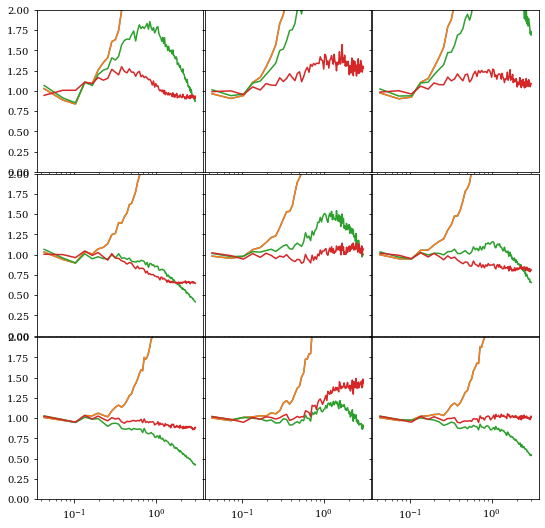

In [86]:
omega_hi = np.zeros((nrows, ncols, nmodels))
k_max = np.zeros_like(omega_hi)
covs = np.zeros_like(omega_hi)
fig, axes = plt.subplots(nrows, ncols, figsize = (9, 9), gridspec_kw = {'wspace':0.01, 'hspace':0.01}, sharex = True, sharey = True)

for (i, j, m) in itertools.product(range(nrows), range(ncols), range(nmodels)):
    model = models[i, j]
    func = model.getModel(m)
    print(func)
    xdata = model.getK(samples[-1])
    ydata = model.getXpk(samples[-1])
    k_max[i, j, m] = xdata[-1]
    val, cov = curve_fit(func, xdata, ydata)
    omega_hi[i, j, m] = model.omegahi(val[0])
    covs[i, j, m] = cov[0]
    axes[i, j].plot(xdata, func(xdata, val[0]) / ydata)
plt.xscale('log')
plt.ylim(0,2)

1.989084562589042e-06
1.752866494934265e-06
3.0550362070335094e-07
9.280057508534833e-08
2.0417133326506737e-06
2.031817459039976e-06
2.2423506161332997e-07
2.0945048167910788e-08
1.994146314114104e-06
1.9520691931199194e-06
2.2284839624295474e-07
2.417734232974575e-08
8.375563080793589e-07
9.366788953170218e-07
1.379966803933909e-07
1.845618345001929e-08
1.0235009557355573e-06
1.2626664513944757e-06
3.56789037499967e-08
2.6006110304779597e-08
9.122928650788583e-07
1.092028067764264e-06
5.246133395137195e-08
2.1705022694912668e-08
2.999548225239674e-07
4.207731349759763e-07
6.140176720953015e-08
4.1191160136099487e-08
3.673478451796192e-07
5.532947138913504e-07
3.1241042140318454e-08
2.9627380556111636e-08
3.220127672221521e-07
4.6910632664205967e-07
4.551417990172514e-08
3.544868443592193e-08


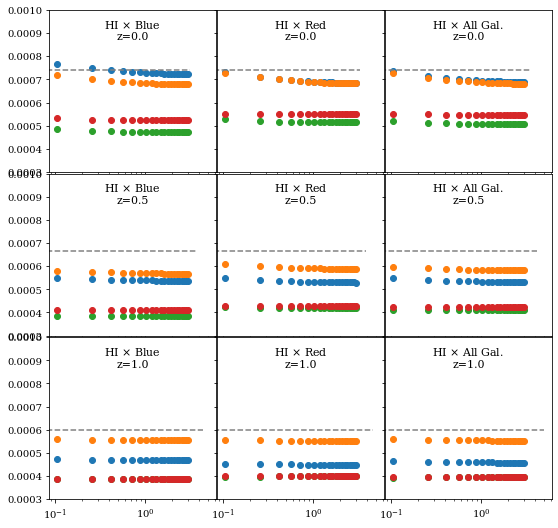

In [73]:
# there's definitely something wrong with this plot - there's no way that there isn't any k-dependence
# in the fit values, since all models should agree at large scales since they all converge to the same values.
# the fact that they don't is telling me that something is up
fig, axes = plt.subplots(nrows, ncols, figsize = (9, 9), gridspec_kw = {'wspace':0.01, 'hspace':0.01}, sharex = True, sharey = True)
labels = ['A', 'B', 'C', 'D']
color_labs = ['HI $\\times$ Blue', 'HI $\\times$ Red', 'HI $\\times$ All Gal.']

for (i, j, m) in itertools.product(range(nrows), range(ncols), range(nmodels)):
    plt.sca(axes[i, j])
    plt.scatter(k_max[i, j, m, :], omega_hi[i, j, m, :], label = 'Model %s'%labels[m])
    print(covs[i, j, m, -1])
for (i, j) in itertools.product(range(nrows), range(ncols)):
    plt.sca(axes[i, j])
    xlim = plt.xlim()
    plt.plot(xlim, [omegahis[i]]*2, linestyle = 'dashed', color = 'gray', label = r'$\Omega_{HI, TNG}$')
    plt.text(0.5, 0.95, '%s\nz=%.1f'%(color_labs[j], redshifts[i]), transform = axes[i, j].transAxes, ha = 'center', va = 'top', fontsize = 11)
    plt.ylim(0.0003, 0.001)

plt.xscale('log')

# making one panel of this plot

In [16]:
# nmodels = 4
# sample_start = 0; sample_end = 100; sample_spacing = 20
# samples = np.arange(sample_start, sample_end, sample_spacing)
from scipy.integrate import quad
from scipy.optimize import curve_fit
snapshot = 67; snap_idx = 1
color = 'blue'
def modelA(k, C):
    c_idx = color_idxs.index(color)
    boost = kaiser(redshifts[snap_idx], 1)
    kmask = (ptlpks[snap_idx][0] >= np.min(k)) & (ptlpks[snap_idx][0] <= np.max(k))
    return bhi[snap_idx] * biases[c_idx][snap_idx] * ccs[c_idx][snap_idx] * ptlpks[snap_idx][1][kmask] * boost * C

def modelB(k, C):
    c_idx = color_idxs.index(color)
    boost = kaiserX(redshifts[snap_idx], bhi[snap_idx], biases[i][snap_idx], ccs[i][snap_idx])
    kmask = (ptlpks[snap_idx][0] >= np.min(k)) & (ptlpks[snap_idx][0] <= np.max(k))
    return bhi[snap_idx] * biases[c_idx][snap_idx] * ccs[c_idx][snap_idx] * ptlpks[snap_idx][1][kmask] * boost * C

def integrandX(mu, k, real_pk, f, bias1, bias2, cc, sigma1, sigma2):
    kaiser = real_pk * (1 + f*mu**2/cc/bias1 + f*mu**2/cc/bias2 + f**2 * mu**4 / bias1 /bias2 / cc)
    fog = 1/(1 + 0.5 * k**2 * mu**2 * sigma1**2)/(1 + 0.5 * k**2 * mu**2 * sigma2**2)
    return kaiser * fog

def solve_integralX(k, real_pk, z, bias1, bias2, cc, sigma1, sigma2):
    # Define the limits of integration
    lower_limit = -1.0
    upper_limit = 1.0
    
    D = cosmo.growthFactor(z, derivative = 0)
    dDdz = cosmo.growthFactor(z, derivative = 1)
    f = -dDdz * (z + 1) / D
    # Use quad from scipy to perform the numerical integration
    result, error = quad(integrandX, lower_limit, upper_limit, args=(k, real_pk, f, bias1, bias2, cc, sigma1, sigma2)) 
    return result * 0.5

def modelC(k, C):
    c_idx = color_idxs.index(color)
    ip = {'is_auto':False, 'fieldname':'galaxy',
          'axis':0, 'grid_resolution':800, 'simname': ['tng300'],
          'post_process':['obs_bias'], 'snapshot':[snapshot], 'space':'real',
         'path':'fiducial', 'denominator':'ptl', '_post_time':'now'}
    ip['color'] = color
    
    kdep_galbias = ds.getMatching(ip)[0].getData()[1]
    
    ip = {'is_auto':False, 'post_process':'corr_coef', 'HI_fieldname':['vn'], 'space':['real'], 'gal_res':'diemer',
      'gal_species':'stmass', 'snapshot':[snapshot], 'simname':'tng300',
      'censat':['no key found', 'both'], 'mas':'CICW',
     'path':'fiducial'}
    ip['color'] = color
    kdep_cc = ds.getMatching(ip)[0].getData()[1]
    boost = kaiserX(redshifts[snap_idx], bhi[snap_idx], biases[c_idx][snap_idx], ccs[c_idx][snap_idx])
    pk = np.zeros_like(k)
    for i, kval in enumerate(k):
        pk[i] = solve_integralX(kval, bhi[snap_idx] * biases[c_idx][snap_idx] * ccs[c_idx][snap_idx] * ptlpks[snap_idx][1][i],
                            redshifts[snap_idx], bhi[snap_idx], biases[c_idx][snap_idx], ccs[c_idx][snap_idx],
                            sighi[snap_idx], sigmas[c_idx][snap_idx])
    return pk * C

ip = {'is_auto':False, 'HI_fieldname':['vn'], 
      'axis':0, 'grid_resolution':800, 'simname': 'tng300', 
      'snapshot':[snapshot], 'color_cut':['0.60', '0.55', '0.50', 'None'], 'gal_res':'diemer',
      'gal_species':'stmass', 'sim_resolution':'high', 'post_process':'no key found',
      'mas':'CICW', 'space':['redshift']}
ip['color'] = color
xpk = ds.getMatching(ip)[0].getData()

ksamples = [2, 10, 20, 50, 100, 200, 500]
resultsC = []; resultsA = []; resultsB = []
kvals = []
for k in range(len(ksamples)):
    xdata = xpk[0][:ksamples[k]]
    ydata = xpk[1][:ksamples[k]]
    kvals.append(xdata[-1])
    val, cov = curve_fit(modelC, xdata, ydata * thi(), p0 = (thi()))
    resultsC.append(val[0])
    val, cov = curve_fit(modelA, xdata, ydata * thi(), p0 = (thi()))
    resultsA.append(val[0])
    val, cov = curve_fit(modelB, xdata, ydata * thi(), p0 = (thi()))
    resultsB.append(val[0])
print(resultsA, resultsB, resultsC)

2 2
10 10
20 20
50 50
100 100
200 200
500 500
[0.0907059436556926, 0.0903813388597429, 0.08987234586039522, 0.08938039197482375, 0.08921754960323723, 0.08917780102214334, 0.08917207756207074] [0.09923971424819517, 0.09888457006736066, 0.09832769009699958, 0.09778945233879216, 0.09761128953020365, 0.0975678012619905, 0.0975615393860538] [0.09719234734289602, 0.09813879679202052, 0.09816459595895527, 0.09817739048228327, 0.09818007919282325, 0.09818066849355127, 0.09818076916548366]


IndexError: string index out of range

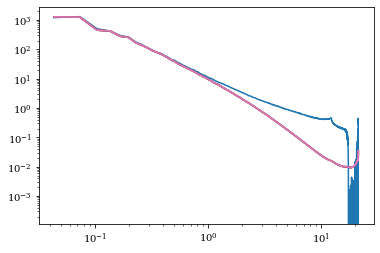

In [17]:
plt.loglog(xpk[0], xpk[1] * thi(), label = 'actual')
alpha = 'abcdef'
for i, result in enumerate(results):
    plt.plot(xpk[0], modelC(xpk[0], result), label = 'model %s'%alpha[i])
plt.legend()

In [18]:
print(omegahi(np.array(resultsA)))
print(omegahi(np.array(resultsB)))
print(omegahi(np.array(resultsC)))


[0.00054535 0.0005434  0.00054034 0.00053738 0.0005364  0.00053616
 0.00053613]
[0.00059666 0.00059452 0.00059117 0.00058794 0.00058687 0.0005866
 0.00058657]
[0.00058435 0.00059004 0.00059019 0.00059027 0.00059029 0.00059029
 0.00059029]
